In [128]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import pandas as pd

# Import du processeur de production spécialisé
from tools.OI_class_OP import OI_ProductionProcessor
from tools.OI_Dashboard import ProductionDashboard
from tools.OI_Dashboard_v2 import AjouterVisualisationsAvancees


# Configuration de l'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [129]:
# Cellule 2 : Définition des métadonnées de tags API
tags = [
    {'tag':'WQ33222VA', 'nom':'ester_cons','info':'Totalisation du Peson Acetate/Propionate' },
    {'tag':'NOP_ESTERS', 'nom':'ester_nop','info':"Nombres des opérations d'esters" },
    {'tag':'3340_type', 'nom':'A/P','info':'Acetate ou Propionate' },
    {'tag':'CTY_ACV43A_Teneur Vit. A (UV)', 'nom':'Acetate_UV','info':'ACV43A teneur en acetate'},
    {'tag':'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom':'Propionate_UV', 'info':'A3340FGB teneur en propionate'},
    {'tag':'PU3310VA_Sign','nom':'PU3310','info':'signature du PU3310'},
    {'tag':'PU3320VA_Sign','nom':'PU3320','info':'signature du PU3320'},
    {'tag':'PU3340VA_Sign','nom':'PU3340','info':'signature du PU3340'},
    {'tag':'FQ32202VA_UV','nom':'Hexane','info':'VA diluée dans de l\'hexane'},
    {'tag':'CTY_A3230A_Teneur en rétinol', 'nom':'Retinol_UV','info':'A3230A teneur en rétinol lavé'},
    {'tag':'LI33203VA','nom':'R33020','info':'niveau du R33020'},
    {'tag':'LI33218VA','nom':'R33022','info':'niveau du R33022'},
    {'tag':'LI33225VA','nom':'R33061','info':'niveau du R33061'},
    {'tag':'WI33222VA','nom':'R33060','info':'peson du R33060'},
    {'tag':'FQ32202VA','nom':'retinol_cons','info':'peson du R33060'},
    {'tag':'LI32209VA','nom':'R32031','info':'niveau du R32031'},
]

In [130]:
# Cellule 3 : Variable Produits unifiée (Acetate & Propionate)
# Plus aucune distinction batch / continu pour le calcul global du stock d'un produit.
produits = [
    {
        'nom': 'Ester',
        'conso': {
            'value': 'ester_cons',
            'scale': 1e-9,
            'type':'A/P',
            'uv': ['Acetate_UV', 'Propionate_UV'],
        },
        'CMJ': 9.7,
        'NOP': {
            'value':'NOP_ESTERS',
            'scale': 1,
            'type': None,
        },
        'stock': [
            # Batchs
            {'pu': 'PU3310', 'in': 540, 'out': 710, 'value': 'Hexane', 'uv': 'Retinol_UV', 'scale': 1/(825 * 100.)},
            {'pu': 'PU3310', 'in': 710, 'out': 2320, 'value': None, 'uv': None, 'scale': 2.71},
            {'pu': 'PU3320', 'in': 430, 'out': 2020, 'value': None, 'uv': None, 'scale': 2.71},
            # Continus
            {'pu': None, 'value': 'R33020', 'min': 14, 'epalage': [[28.62, 21.22, 3.866, -0.0983], [-228.84, 74.557]], 'uv': 'Retinol_UV', 'scale': 1/100., 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': None, 'value': 'R33022', 'min': 14, 'epalage': [[6.25, 5.4525, 0.898, -0.0256], [-35, 97, 16.039]], 'uv': 'Retinol_UV', 'scale': 1/100., 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': None, 'value': 'R33061', 'min': 18, 'epalage': [[0.69, 0.72, 0.296, -0.0059], [-30.03, 5.836]], 'uv': None, 'scale': 0.95 , 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': 'PU3340', 'in': 0, 'out': 710, 'value': 'R33060', 'uv': None, 'scale': 0.95, 'cond': 'A/P', 'val_cond': [1/344, 1/359]}
        ]
    },
    {
        'nom': 'Retinol',
        'conso': {
            'value':'retinol_cons',
            'scale': 1e-5, # Ajustement de l'échelle pour le retinol g et analyse en %
            'uv': ['Retinol_UV','Retinol_UV'],
        },
        'CMJ': 1,
        'stock': [
            # Batchs
            {'pu': None, 'value': 'R32031', 'uv': 'Retinol_UV', 'scale': 1/(825 * 100.)},
        ]
    }
]

In [131]:
# Cellule 4 : Initialisation du processeur de production spécialisé
processor = OI_ProductionProcessor(
    url_base = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    start = '2026-01-01',
    end = '2026-12-31',
    tags_metadata = tags,
    produits = produits,
    interval = 'PT20M',
    verbose = False
)

In [132]:
# Cellule 5 : Téléchargement et calcul automatique des bilans par produit
processor.merge()
processor.compute_production_balance()

# Visualisation des premières lignes calculées
processor.data.describe()

,ester_cons,ester_nop,A/P,Acetate_UV,Propionate_UV,PU3310,PU3320,PU3340,Hexane,Retinol_UV,R33020,R33022,R33061,R33060,retinol_cons,R32031,consommation_Ester,stock_Ester,consommation_Retinol,stock_Retinol,conso_delta_Ester,delta_stock_Ester,production_Ester,conso_delta_Retinol,delta_stock_Retinol,production_Retinol
count,1.094500e+04,10945.000000,10945.000000,1.094500e+04,1.094500e+04,10942.000000,10943.000000,10941.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000,10945.000000
mean,2.450846e+06,1961.847722,0.075972,2.226187e+06,2.280963e+06,1014.083562,941.682249,461.942737,2567.407237,20.788622,45.635045,4.983801,7.203124,685.943191,463509.866168,47.668143,511.542883,6.665617,394192.436915,0.012010,511.542883,0.438205,511.981088,394192.436915,-0.002159,394192.434756
std,1.436499e+05,117.782432,0.264839,3.851751e+04,5.140042e+04,597.976835,529.115755,111.589615,1860.653057,0.369587,20.336947,2.409495,10.965120,344.892103,251381.565449,20.449558,321.439266,2.245600,487334.506775,0.005155,321.439266,2.245600,321.983618,487334.506775,0.005155,487334.507057
min,2.221310e+06,1774.000000,0.000000,2.078915e+06,2.188000e+06,100.000000,100.000000,313.116667,0.000000,20.000000,-7.918751,-0.695313,-0.337315,6.278194,640.456000,0.220855,0.000000,0.724677,0.000000,0.000056,0.000000,-5.502735,-1.516407,0.000000,-0.014113,0.000000
25%,2.314830e+06,1851.000000,0.000000,2.221983e+06,2.242000e+06,400.000000,400.000000,410.000000,0.000000,20.600000,24.087119,3.621251,2.215957,427.009153,249644.000000,39.729039,207.463864,5.540087,65.520073,0.010006,207.463864,-0.687326,208.978234,65.520073,-0.004163,65.516256
50%,2.435050e+06,1948.000000,0.000000,2.231260e+06,2.314000e+06,1310.000000,1113.733333,410.000000,3932.160000,20.800000,45.008028,5.953130,2.963799,683.309387,433005.000000,45.016141,474.375934,7.042875,149.891636,0.011511,474.375934,0.815462,477.320773,149.891636,-0.002659,149.896589
75%,2.576370e+06,2065.000000,0.000000,2.245049e+06,2.314000e+06,1310.000000,1298.108333,410.000000,4036.910000,21.200000,64.483315,6.518274,4.150035,941.450200,668183.000000,66.817031,792.248941,8.166313,996793.026724,0.016765,792.248941,1.938900,791.392726,996793.026724,0.002596,996793.023815
max,2.714510e+06,2179.000000,1.000000,2.325113e+06,2.626000e+06,2320.033333,2249.987500,810.000000,4836.070000,21.200000,91.504357,12.239069,68.457970,1321.036235,997389.108434,79.734400,1103.546722,12.528535,996888.325007,0.019909,1103.546722,6.301123,1106.210968,996888.325007,0.005740,996888.327637


<Axes: xlabel='timestamp'>

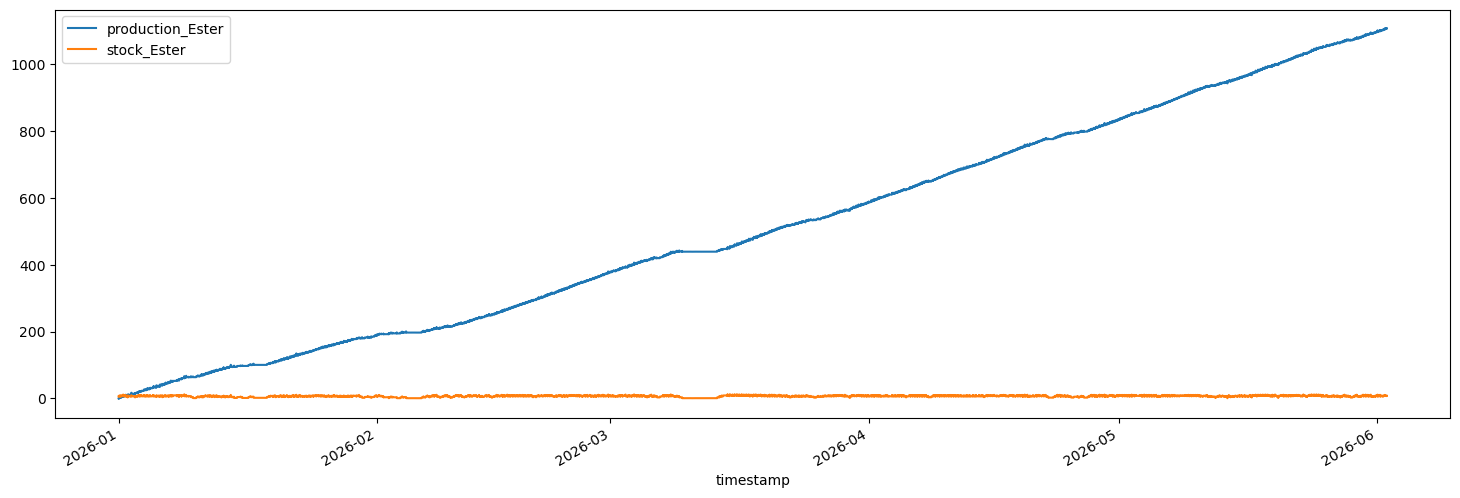

In [133]:
processor.data.loc[:, ['production_Ester', 'stock_Ester']].plot(figsize=(18,6))

In [134]:
# ✨ INITIALISER LE DASHBOARD ✨
dashboard = ProductionDashboard(processor)
AjouterVisualisationsAvancees(dashboard) 
 
print("\n✓ Dashboard prêt pour utilisation!")


✓ Dashboard initialisé
  Produits: Ester, Retinol
  Période: 2026-01-01 → 2026-06-02
✅ Visualisations avancées ajoutées au dashboard!

   Nouvelles méthodes disponibles:
   • dashboard.plot_histogramme_tous_produits(mois=3)
   • dashboard.plot_waterfall_mois(mois=3)
   • dashboard.plot_histogramme_jours_mois_v1(mois=3, nom_produit='Ester')
   • dashboard.plot_histogramme_jours_mois_v2(mois=3, nom_produit='Ester')


✓ Dashboard prêt pour utilisation!


In [135]:
# Afficher le résumé complet
dashboard.resume_complet()



  RÉSUMÉ COMPLET DU DASHBOARD

📅 Période de données: 2026-01-01 → 2026-06-02
📦 Produits disponibles: Ester, Retinol

  EXEMPLE D'UTILISATION

# Afficher les KPIs d'un jour
dashboard.afficher_kpis_journaliers(jour=15, mois=3, annee=2024)

# Afficher les KPIs d'un mois
dashboard.afficher_kpis_mensuels(mois=3, annee=2024)

# Voir le bilan graphique d'une journée
dashboard.afficher_bilan_journalier(jour=15, mois=3)

# Voir l'évolution d'un produit
dashboard.afficher_bilan_produit('Acetate')

# Comparer les N derniers jours
dashboard.afficher_comparaison_jours(num_jours=7)
        



In [136]:
# Voir l'évolution temporelle d'un produit
dashboard.afficher_bilan_produit('Ester')


In [137]:
dashboard.afficher_kpis_mensuels(mois=5,annee=2026)

____________________________________________________________
BILAN MENSUEL - MAI 2026 (Terminé)
Période : du 01/05/2026 à 02:00 au 01/06/2026 à 02:00
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 263.8927
  Variation de Stock     : -2.5546
  Production             : 261.3381
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 79.0581
  Variation de Stock     : 0.0060
  Production             : 79.0641
____________________________________________________________
____________________________________________________________

  KPIS MENSUELS - MAY 2026
  Production Mensuelle           :       340.40 unités         
  Consommation Mensuelle         :       342.95 unités         
  Variation Stock                :        -2.55 unités         



[KPI(nom='Production Mensuelle', valeur=340.402216068557, unite='unités', variation=None, couleur='#4CAF50'),
 KPI(nom='Consommation Mensuelle', valeur=342.9508231728803, unite='unités', variation=None, couleur='#FF9800'),
 KPI(nom='Variation Stock', valeur=-2.5486071043767557, unite='unités', variation=None, couleur='#F44336')]

In [138]:
dashboard.afficher_kpis_journaliers(jour=31, mois=5, annee=2026)

____________________________________________________________
BILAN JOURNALIER - 31 MAI 2026 (Terminé)
Période : du 31/05/2026 à 02:00 au 01/06/2026 à 02:00
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 8.3226
  Variation de Stock     : -3.5124
  Stock Entrée.          : 2.6191
  Stock Sortie.          : -0.8933
  Production             : 4.8102
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 1.6025
  Variation de Stock     : 0.0002
  Stock Entrée.          : -0.0031
  Stock Sortie.          : -0.0029
  Production             : 1.6027
____________________________________________________________
____________________________________________________________

  KPIS JOURNALIERS - 31/5/2026
  Production Totale              :         6.41 unités         
  Co

[KPI(nom='Production Totale', valeur=6.412865755951316, unite='unités', variation=None, couleur='#4CAF50'),
 KPI(nom='Consommation', valeur=9.925073800071914, unite='unités', variation=None, couleur='#FF9800'),
 KPI(nom='Variation Stock', valeur=-3.5122080441129637, unite='unités', variation=None, couleur='#F44336')]

In [139]:
dashboard.plot_histogramme_tous_produits(mois=5)


____________________________________________________________
BILAN MENSUEL - MAI 2026 (Terminé)
Période : du 01/05/2026 à 02:00 au 01/06/2026 à 02:00
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 263.8927
  Variation de Stock     : -2.5546
  Production             : 261.3381
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 79.0581
  Variation de Stock     : 0.0060
  Production             : 79.0641
____________________________________________________________
____________________________________________________________



  📋 RÉSUMÉ - HISTOGRAMME MAY 2026
Produit              Production         Consommation       Var. Stock         Efficacité     
-----------------------------------------------------------------------------------------------
Ester                261.34             263.89             -2.55              99.0           %
Retinol              79.06              79.06              0.01               100.0          %
-----------------------------------------------------------------------------------------------
TOTAL                340.40             342.95             -2.55             



In [140]:
dashboard.afficher_kpis_mensuels(mois=5, annee=2026)

____________________________________________________________
BILAN MENSUEL - MAI 2026 (Terminé)
Période : du 01/05/2026 à 02:00 au 01/06/2026 à 02:00
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 263.8927
  Variation de Stock     : -2.5546
  Production             : 261.3381
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 79.0581
  Variation de Stock     : 0.0060
  Production             : 79.0641
____________________________________________________________
____________________________________________________________

  KPIS MENSUELS - MAY 2026
  Production Mensuelle           :       340.40 unités         
  Consommation Mensuelle         :       342.95 unités         
  Variation Stock                :        -2.55 unités         



[KPI(nom='Production Mensuelle', valeur=340.402216068557, unite='unités', variation=None, couleur='#4CAF50'),
 KPI(nom='Consommation Mensuelle', valeur=342.9508231728803, unite='unités', variation=None, couleur='#FF9800'),
 KPI(nom='Variation Stock', valeur=-2.5486071043767557, unite='unités', variation=None, couleur='#F44336')]

In [144]:
dashboard.plot_histogramme_jours_mois_v2(mois=6, annea=2026, nom_produit='Ester')

____________________________________________________________
BILAN JOURNALIER - 01 JUIN 2026 (Terminé)
Période : du 01/06/2026 à 02:00 au 02/06/2026 à 02:00
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 8.3173
  Variation de Stock     : 2.4297
  Stock Entrée.          : -0.8933
  Stock Sortie.          : 1.5364
  Production             : 10.7470
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 3.3908
  Variation de Stock     : 0.0055
  Stock Entrée.          : -0.0029
  Stock Sortie.          : 0.0026
  Production             : 3.3963
____________________________________________________________
____________________________________________________________
____________________________________________________________
BILAN JOURNALIER - 02 JUIN 2026 (À date


  📊 STATISTIQUES - PRODUCTION ESTER PAR JOUR - JUNE 2026
Nombre de jours complets:           2
Production moyenne:                 5.38
Production min/max:                 0.01 / 10.75
Écart-type:                         5.37
Coefficient de variation:           99.8%
Production totale mois:             10.76
TRS mois: (jours complets)          5.38
Jours au-dessus de la moyenne:      1 / 2

🎯 RATIO OOE (Production / CMJ en %):
  CMJ (Cible Journalière):            9.70
  OOE Moyen (par jour):               55.5%
  OOE Min/Max (par jour):             0.1% / 110.8%
  OOE Cumulé à date:                  55.5%
  Jours > 100%:                       1 / 2

  Détail OOE par jour:
    J01:  110.8% ✅
    J02:    0.1% ❌



In [145]:
dashboard.afficher_bilan_journalier(jour=2, mois=6, annee=2026)

____________________________________________________________
BILAN JOURNALIER - 02 JUIN 2026 (À date (En cours))
Période : du 02/06/2026 à 02:00 au 02/06/2026 à 04:00
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 0.0000
  Variation de Stock     : 0.0114
  Stock Entrée.          : 1.5364
  Stock Sortie.          : 1.5478
  Production             : 0.0114
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 0.0000
  Variation de Stock     : -0.0165
  Stock Entrée.          : 0.0026
  Stock Sortie.          : -0.0139
  Production             : -0.0165
____________________________________________________________
____________________________________________________________


In [143]:
dashboard.plot_histogramme_annuee(annea=2026, nom_produit='Ester')

____________________________________________________________
BILAN JOURNALIER - 01 JANVIER 2026 (Terminé)
Période : du 01/01/2026 à 02:00 au 02/01/2026 à 02:00
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 8.2673
  Variation de Stock     : -5.4382
  Stock Entrée.          : 2.4330
  Stock Sortie.          : -3.0052
  Production             : 2.8291
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 2.6224
  Variation de Stock     : 0.0007
  Stock Entrée.          : -0.0032
  Stock Sortie.          : -0.0025
  Production             : 2.6231
____________________________________________________________
____________________________________________________________
____________________________________________________________
BILAN JOURNALIER - 02 JANVIER 2026 


  📊 RÉSUMÉ ANNUEL 2026 - Ester
Mois         Jours    Prod Total      Prod Moy        OOE Moy      OOE Cumul   
----------------------------------------------------------------------------------------------------
January      29       186.83          6.44            66.4        % 66.4        %
February     26       188.30          7.24            74.7        % 74.7        %
March        28       209.07          7.47            77.0        % 77.0        %
April        30       246.90          8.23            84.8        % 84.8        %
May          31       261.34          8.43            86.9        % 86.9        %
June         2        10.76           5.38            55.5        % 55.5        %

